In [1]:
# Stock prices
# Weather 
# Econometrics data
# Events data from web page activity (for digitial marketing)
# Marketing campaign metrics

In [2]:
# Stock tick data 
# Data handling is the backbone of timeseries analysis
# Pandas supports time zones and uses NumPy's datetime64[ns] data type # resolution upto nanoseconds

In [3]:
# DataFrames allow you to work with various time-based indices
# DatetimeIndex is the most common one and represents an index with timestamps
# PeriodIndex is based on time intervals such as hours and months

# DatetimeIndex using pd.date_range()

In [4]:
import pandas as pd 
import numpy as np
pd.options.plotting.backend = 'plotly'

In [6]:
daily_index = pd.date_range("2020-02-28",periods=10,freq="D")
daily_index

DatetimeIndex(['2020-02-28', '2020-02-29', '2020-03-01', '2020-03-02',
               '2020-03-03', '2020-03-04', '2020-03-05', '2020-03-06',
               '2020-03-07', '2020-03-08'],
              dtype='datetime64[ns]', freq='D')

In [7]:
weekly_index = pd.date_range("2020-01-01", "2020-01-31", freq="W-SUN")
weekly_index

DatetimeIndex(['2020-01-05', '2020-01-12', '2020-01-19', '2020-01-26'], dtype='datetime64[ns]', freq='W-SUN')

In [8]:
# construct a DataFrame based on the weekly_index

pd.DataFrame(data = [21, 15, 33, 34],
             columns = ["visitors"],
             index = weekly_index)

,visitors
2020-01-05,21
2020-01-12,15
2020-01-19,33
2020-01-26,34


In [9]:
msft = pd.read_csv('csv/MSFT.csv')
msft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8622 entries, 0 to 8621
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       8622 non-null   object 
 1   Open       8622 non-null   float64
 2   High       8622 non-null   float64
 3   Low        8622 non-null   float64
 4   Close      8622 non-null   float64
 5   Adj Close  8622 non-null   float64
 6   Volume     8622 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 471.6+ KB


## 1. Use pd.to_datetime() to convert object dtype to datetime64[ns]

In [10]:
# date is a string in object data type

msft['Date']=pd.to_datetime(msft['Date'])
msft.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1986-03-13,0.088542,0.101563,0.088542,0.097222,0.062205,1031788800
1,1986-03-14,0.097222,0.102431,0.097222,0.100694,0.064427,308160000
2,1986-03-17,0.100694,0.103299,0.100694,0.102431,0.065537,133171200
3,1986-03-18,0.102431,0.103299,0.098958,0.099826,0.063871,67766400
4,1986-03-19,0.099826,0.100694,0.097222,0.098090,0.062760,47894400


In [16]:
msft['Volume']=msft['Volume'].astype("float")

In [17]:
msft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8622 entries, 0 to 8621
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       8622 non-null   datetime64[ns]
 1   Open       8622 non-null   float64       
 2   High       8622 non-null   float64       
 3   Low        8622 non-null   float64       
 4   Close      8622 non-null   float64       
 5   Adj Close  8622 non-null   float64       
 6   Volume     8622 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 471.6 KB


In [20]:
msft['Volume']=msft['Volume'].astype("Int64")

In [21]:
msft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8622 entries, 0 to 8621
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       8622 non-null   datetime64[ns]
 1   Open       8622 non-null   float64       
 2   High       8622 non-null   float64       
 3   Low        8622 non-null   float64       
 4   Close      8622 non-null   float64       
 5   Adj Close  8622 non-null   float64       
 6   Volume     8622 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), float64(5)
memory usage: 480.1 KB


In [14]:
msft.loc[:,'Date'] = pd.to_datetime(msft['Date'])
msft.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

## 2. Use parse_dates argument when reading the csv file 

In [18]:
msft = pd.read_csv('csv/MSFT.csv', parse_dates=['Date'])
msft.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

In [19]:
msft = pd.read_csv('csv/MSFT.csv', index_col='Date', parse_dates=['Date'])
msft.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1986-03-13,0.088542,0.101563,0.088542,0.097222,0.062205,1031788800
1986-03-14,0.097222,0.102431,0.097222,0.100694,0.064427,308160000
1986-03-17,0.100694,0.103299,0.100694,0.102431,0.065537,133171200
1986-03-18,0.102431,0.103299,0.098958,0.099826,0.063871,67766400
1986-03-19,0.099826,0.100694,0.097222,0.098090,0.062760,47894400


## in pandas, the **dtype** parameter only accepts NumPy dtypes like int, float, or str. 
## It does not support datetime objects.

In [23]:
msft = pd.read_csv('csv/MSFT.csv',
                   dtype = {'Volume': float}, # keep numeric fields as float and not convert to integer
                   parse_dates = ['Date'])  # parse_dates=[["Date", "Time", ...]]  # combines Date fields
msft.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object

In [26]:
## astype("float"), astype("bool"), astype("int"), astype("string")

msft['Volume'] = msft['Volume'].astype('Int64')

In [27]:
msft.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                Int64
dtype: object

## .astype('int64') will truncate the decimals, not round them.

In [37]:
s = pd.Series([123.9, 456.1])
s.astype('int64')  # results in [123, 456]

0    123
1    456
dtype: int64

In [39]:
msft['Volume'].isna().sum()

np.int64(0)

In [41]:
msft.Volume.dtype

dtype('float64')

In [22]:
msft.loc[:, 'Volume'] = msft['Volume'].astype('Int64')
msft.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                Int64
dtype: object

In [28]:
import pandas as pd
s = pd.Series([1.0, 2.0, 3.0])
s_int = s.astype('int')       # or s.astype('int64')
print(s_int.dtype)            # int64

int64


In [30]:
s = pd.Series([1.0, 2.0, None])
s_int = s.astype('Int64')       # or s.astype('int64')
print(s_int.dtype)            # int64

Int64


In [31]:
s

0    1.0
1    2.0
2    NaN
dtype: float64

In [34]:
msft = pd.read_csv('csv/MSFT.csv', index_col='Date', parse_dates=['Date'])
msft.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1986-03-13,0.088542,0.101563,0.088542,0.097222,0.062205,1031788800
1986-03-14,0.097222,0.102431,0.097222,0.100694,0.064427,308160000
1986-03-17,0.100694,0.103299,0.100694,0.102431,0.065537,133171200
1986-03-18,0.102431,0.103299,0.098958,0.099826,0.063871,67766400
1986-03-19,0.099826,0.100694,0.097222,0.098090,0.062760,47894400


In [35]:
# With time series always make sure that the index is sorted properly before your analysis

msft= msft.sort_index()

In [36]:
msft.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1986-03-13,0.088542,0.101563,0.088542,0.097222,0.062205,1031788800
1986-03-14,0.097222,0.102431,0.097222,0.100694,0.064427,308160000
1986-03-17,0.100694,0.103299,0.100694,0.102431,0.065537,133171200
1986-03-18,0.102431,0.103299,0.098958,0.099826,0.063871,67766400
1986-03-19,0.099826,0.100694,0.097222,0.098090,0.062760,47894400


In [37]:
msft.index

DatetimeIndex(['1986-03-13', '1986-03-14', '1986-03-17', '1986-03-18',
               '1986-03-19', '1986-03-20', '1986-03-21', '1986-03-24',
               '1986-03-25', '1986-03-26',
               ...
               '2020-05-13', '2020-05-14', '2020-05-15', '2020-05-18',
               '2020-05-19', '2020-05-20', '2020-05-21', '2020-05-22',
               '2020-05-26', '2020-05-27'],
              dtype='datetime64[ns]', name='Date', length=8622, freq=None)

## Filtering using the DatetimeIndex 

In [38]:
msft.loc["2019","Adj Close"]

Date
2019-01-02     99.099190
2019-01-03     95.453529
2019-01-04     99.893005
2019-01-07    100.020401
2019-01-08    100.745613
                 ...    
2019-12-24    156.515396
2019-12-26    157.798309
2019-12-27    158.086731
2019-12-30    156.724243
2019-12-31    156.833633
Name: Adj Close, Length: 252, dtype: float64

In [39]:
msft.loc["2019-05":"2019-06","Volume"]

Date
2019-05-01    26821700
2019-05-02    27350200
2019-05-03    24911100
2019-05-06    24239800
2019-05-07    36017700
2019-05-08    28419000
2019-05-09    27235800
2019-05-10    30915100
2019-05-13    33944900
2019-05-14    25266300
2019-05-15    24722700
2019-05-16    30112200
2019-05-17    25770500
2019-05-20    23706900
2019-05-21    15293300
2019-05-22    15396500
2019-05-23    23603800
2019-05-24    14123400
2019-05-28    23128400
2019-05-29    22763100
2019-05-30    16829600
2019-05-31    26646800
2019-06-03    37983600
2019-06-04    29382600
2019-06-05    24926100
2019-06-06    21459000
2019-06-07    33885600
2019-06-10    26477100
2019-06-11    23913700
2019-06-12    17084700
2019-06-13    17200800
2019-06-14    17821700
2019-06-17    14517800
2019-06-18    25934500
2019-06-19    23744400
2019-06-20    33042600
2019-06-21    36727900
2019-06-24    20628800
2019-06-25    33327400
2019-06-26    23657700
2019-06-27    16557500
2019-06-28    30043000
Name: Volume, dtype: int64

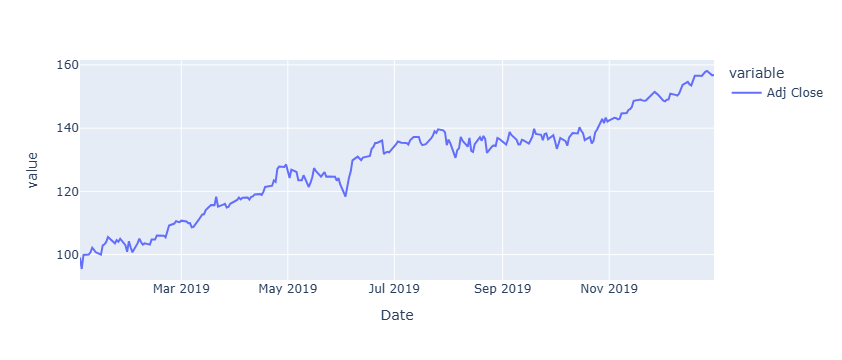

In [40]:
msft.loc["2019-01":"2019-12","Adj Close"].plot()

## Working with timezones

In [42]:
# Add the time information to the date

# Since the closing hour is only applicable to the close price, creating a new DataFrame with it 

msft_close = msft.loc[:, ['Adj Close']].copy()
msft_close.index = msft_close.index + pd.DateOffset(hours=16)
msft_close.head()

,Adj Close
Date,
1986-03-13 16:00:00,0.062205
1986-03-14 16:00:00,0.064427
1986-03-17 16:00:00,0.065537
1986-03-18 16:00:00,0.063871
1986-03-19 16:00:00,0.062760


In [43]:
# Make the timestamps timezone aware

msft_close = msft_close.tz_localize("America/New_York")
msft_close.head()

,Adj Close
Date,
1986-03-13 16:00:00-05:00,0.062205
1986-03-14 16:00:00-05:00,0.064427
1986-03-17 16:00:00-05:00,0.065537
1986-03-18 16:00:00-05:00,0.063871
1986-03-19 16:00:00-05:00,0.062760


In [45]:
msft_close.index.dtype

datetime64[ns, America/New_York]

## Convert the timestamps to UTC time zone, use the **tz_convert** method

In [46]:
msft_close = msft_close.tz_convert("UTC")
msft_close.loc["2020-01-02", "Adj Close"] # 21:00 without DST

Date
2020-01-02 21:00:00+00:00    159.737595
Name: Adj Close, dtype: float64

In [47]:
msft_close.index.dtype

datetime64[ns, UTC]

## Common Time Series Manipulations

#### 1. Calculating Stock Returns
#### 2. Plotting performance of various stocks
#### 3. Visualize the correlation of returns in a heatmap

In [48]:
## log returns lN(A3/A2) -- Natural log  and LOG for base10

In [49]:
msft_close.head()

,Adj Close
Date,
1986-03-13 21:00:00+00:00,0.062205
1986-03-14 21:00:00+00:00,0.064427
1986-03-17 21:00:00+00:00,0.065537
1986-03-18 21:00:00+00:00,0.063871
1986-03-19 21:00:00+00:00,0.062760


In [50]:
msft_close.shift(1).head()

,Adj Close
Date,
1986-03-13 21:00:00+00:00,NaN
1986-03-14 21:00:00+00:00,0.062205
1986-03-17 21:00:00+00:00,0.064427
1986-03-18 21:00:00+00:00,0.065537
1986-03-19 21:00:00+00:00,0.063871


In [52]:
returns = np.log(msft_close / msft_close.shift(1))
returns = returns.rename(columns = {"Adj Close": "returns"})
returns.head()

,returns
Date,
1986-03-13 21:00:00+00:00,NaN
1986-03-14 21:00:00+00:00,0.035097
1986-03-17 21:00:00+00:00,0.017082
1986-03-18 21:00:00+00:00,-0.025749
1986-03-19 21:00:00+00:00,-0.017547


## Plot a histogram with the daily log returns 

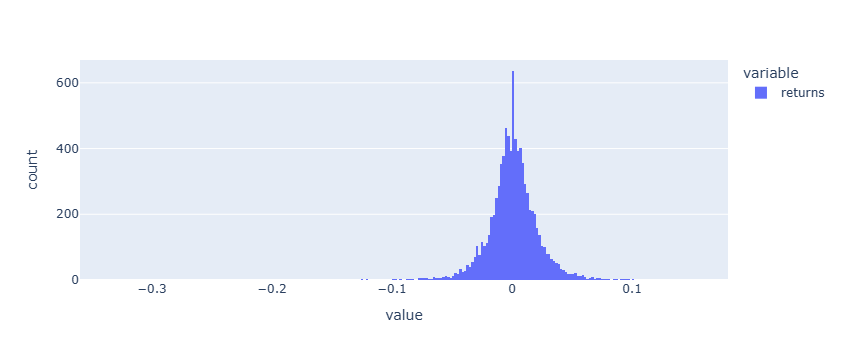

In [56]:
returns = returns.dropna()
returns.plot.hist()

## to get simple_return use **pct_change()** method

In [58]:
simple_returns = msft_close.pct_change()
simple_returns = simple_returns.rename({"Adj Close": "simple returns"})
simple_returns.head()

,Adj Close
Date,
1986-03-13 21:00:00+00:00,NaN
1986-03-14 21:00:00+00:00,0.035721
1986-03-17 21:00:00+00:00,0.017229
1986-03-18 21:00:00+00:00,-0.025421
1986-03-19 21:00:00+00:00,-0.017394


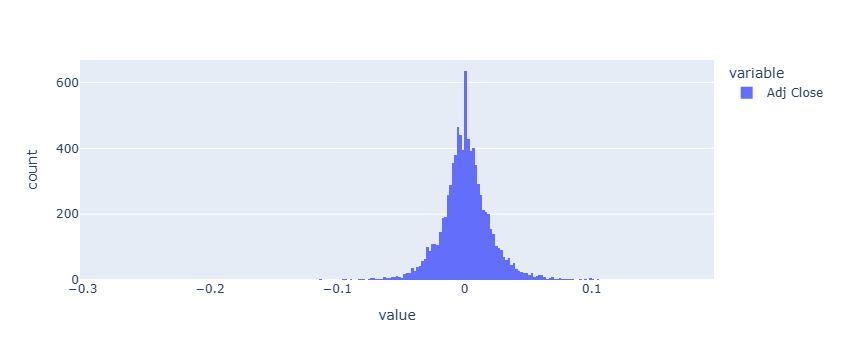

In [65]:
simple_returns.dropna(inplace=True)
simple_returns.plot.hist(bins=100)

In [60]:
np.log(110/100) + np.log(121/110)

np.float64(0.19062035960864987)

In [61]:
np.log(121/100)

np.float64(0.1906203596086497)

In [66]:
## 100 -> 150 = 50% Simple returns
## 150 - 75 = -50% Simple returns

## Not additive

In [68]:
np.log(150/100) + np.log(75/150)

np.float64(-0.2876820724517809)

In [69]:
np.log(75/100)

np.float64(-0.2876820724517809)

In [ ]:
## log returns are additive 
## by central limit theorem sum of r

✅️ Summary

| Type          | Formula     | Pandas                | Used for             |
| ------------- | ----------- | --------------------- | -------------------- |
| Simple return | (P − P₁)/P₁ | pct_change()          | basic analysis       |
| Log return    | log(P / P₁) | np.log(price / shift) | finance / ML / stats |


## Rebasing and Correlation

In [80]:
adj_close_prices = []

cols = ['Date', 'Adj Close']

for ticker in ['AAPL', 'MSFT', 'GOOGL', 'AMZN']:
    adj_close = pd.read_csv(f'csv/{ticker}.csv',
                            index_col = 'Date',
                            parse_dates = ['Date'],
                            usecols = cols)
    adj_close = adj_close.rename(columns = {"Adj Close": ticker})
    adj_close_prices.append(adj_close) 


In [81]:
adj_close_combined = pd.concat(adj_close_prices, axis = 1)
adj_close_combined

,AAPL,MSFT,GOOGL,AMZN
Date,,,,
1980-12-12,0.405683,NaN,NaN,NaN
1980-12-15,0.384517,NaN,NaN,NaN
1980-12-16,0.356296,NaN,NaN,NaN
1980-12-17,0.365115,NaN,NaN,NaN
1980-12-18,0.375698,NaN,NaN,NaN
...,...,...,...,...
2020-05-22,318.890015,183.509995,1413.239990,2436.879883
2020-05-26,316.730011,181.570007,1421.369995,2421.860107
2020-05-27,318.109985,181.809998,1420.280029,2410.389893


In [82]:
adj_close_combined = adj_close_combined.dropna()
adj_close_combined.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3970 entries, 2004-08-19 to 2020-05-27
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    3970 non-null   float64
 1   MSFT    3970 non-null   float64
 2   GOOGL   3970 non-null   float64
 3   AMZN    3970 non-null   float64
dtypes: float64(4)
memory usage: 155.1 KB


## rebase the prices now such that they all start at 100

In [83]:
adj_close_rebased = adj_close_combined / adj_close_combined.iloc[0,:] * 100
adj_close_rebased.head(2)

,AAPL,MSFT,GOOGL,AMZN
Date,,,,
2004-08-19,100.000000,100.000000,100.000000,100.000000
2004-08-20,100.293054,100.294999,107.942996,102.278014


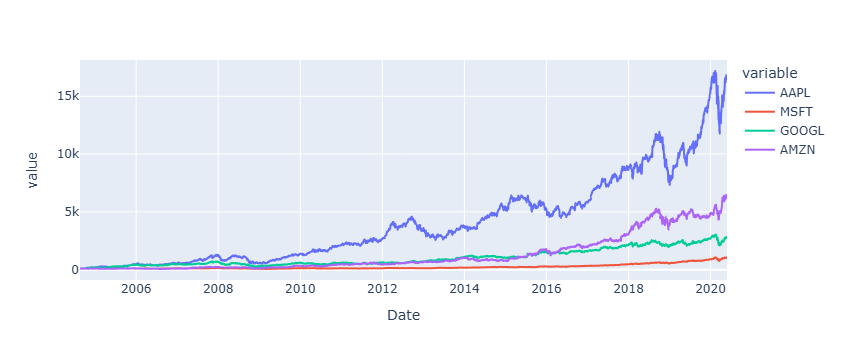

In [84]:
adj_close_rebased.plot()

In [85]:
adj_close_sample = adj_close_combined.loc["2019-06":"2020-05",:]
rebased_prices = adj_close_sample / adj_close_sample.iloc[0,:] *100
rebased_prices.head()

,AAPL,MSFT,GOOGL,AMZN
Date,,,,
2019-06-03,100.000000,100.000000,100.000000,100.000000
2019-06-04,103.658406,102.770372,101.516260,102.178197
2019-06-05,105.331787,104.998342,100.567998,102.706347
2019-06-06,106.878255,106.658885,100.868362,103.643316
2019-06-07,109.723025,109.646189,102.852495,106.577701


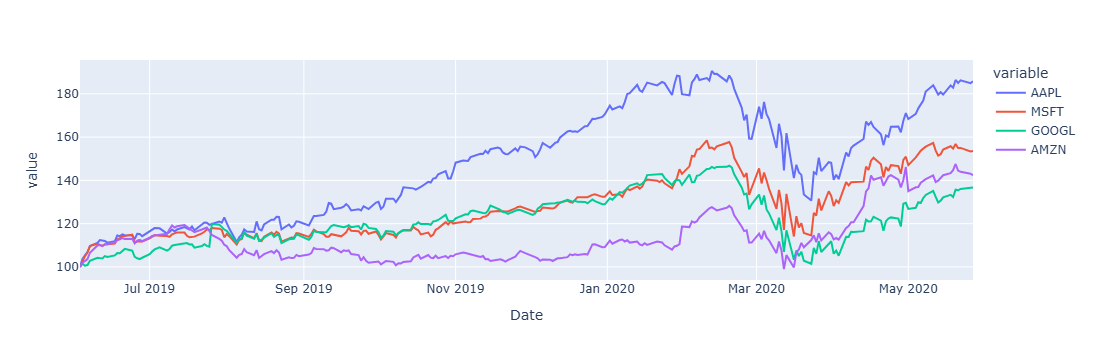

In [86]:
rebased_prices.plot()

## Correlation of daily log returns

In [88]:
returns = np.log(adj_close_combined / adj_close_combined.shift(1))
returns.corr()

,AAPL,MSFT,GOOGL,AMZN
AAPL,1.000000,0.486065,0.503497,0.424910
MSFT,0.486065,1.000000,0.525645,0.485725
GOOGL,0.503497,0.525645,1.000000,0.486690
AMZN,0.424910,0.485725,0.486690,1.000000


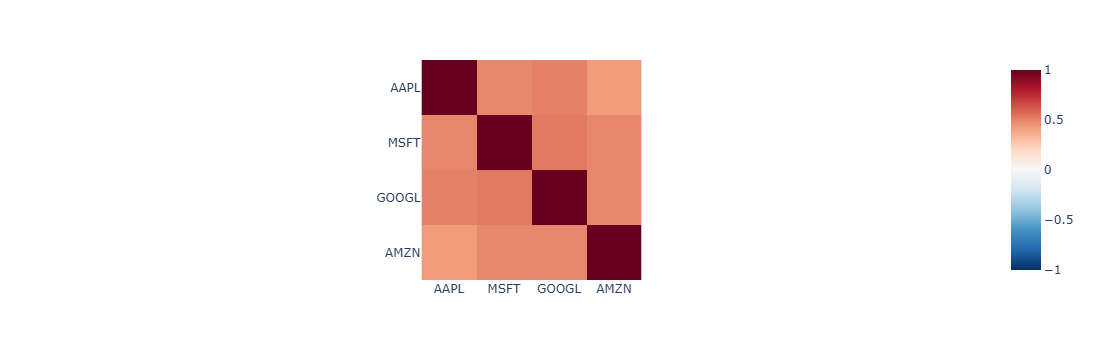

In [89]:
import plotly.express as px
fig = px.imshow(returns.corr(),
                x=adj_close_combined.columns,
                y=adj_close_combined.columns,
                color_continuous_scale=list(
                    reversed(px.colors.sequential.RdBu)),
                zmin=-1, zmax=1)
fig.show()

# Plotly Express API docs (https://oreil.ly/O86li)

## Changing the Frequency of the Time Series Data 

   Resampling   -- Up and downsampling 

   Upsampling   -- Time series is converted into one with a higher frequency
   
   Downsampling -- Time series is converted into one with a lower frequency

## Convert the daily time series into monthly time series, use resample method that accepts a frequency string M or BM
    ME -- End of calendar month
    
    BME -- End of business month

## Pandas frequency strings  (https://oreil.ly/zStpt)

In [95]:
end_of_month = adj_close_combined.resample('ME').last()  ## last tells to take the last observation of the month
end_of_month.head()

,AAPL,MSFT,GOOGL,AMZN
Date,,,,
2004-08-31,2.132708,17.673630,51.236237,38.139999
2004-09-30,2.396127,17.900215,64.864868,40.860001
2004-10-31,3.240182,18.107374,95.415413,34.130001
2004-11-30,4.146072,19.344421,91.081078,39.680000
2004-12-31,3.982207,19.279480,96.491493,44.290001


In [96]:
end_of_business_month = adj_close_combined.resample('BME').last()  ## last tells to take the last observation of the month
end_of_business_month.head()

,AAPL,MSFT,GOOGL,AMZN
Date,,,,
2004-08-31,2.132708,17.673630,51.236237,38.139999
2004-09-30,2.396127,17.900215,64.864868,40.860001
2004-10-29,3.240182,18.107374,95.415413,34.130001
2004-11-30,4.146072,19.344421,91.081078,39.680000
2004-12-31,3.982207,19.279480,96.491493,44.290001


In [ ]:
# gs.resample("W").agg(['mean', 'sum']).head()
# gs.resample("5d").mean().head() 


In [97]:
adj_close_combined.resample('ME').agg(['mean']).head() 

,AAPL,MSFT,GOOGL,AMZN
,mean,mean,mean,mean
Date,,,,
2004-08-31,2.028274,17.672923,52.683795,39.275555
2004-09-30,2.268481,17.706922,56.670241,40.548095
2004-10-31,2.743319,18.206949,76.692168,38.265715
2004-11-30,3.553364,19.153345,88.836454,38.353810
2004-12-31,3.988307,19.531694,90.975975,40.663636


In [98]:
end_of_month

,AAPL,MSFT,GOOGL,AMZN
Date,,,,
2004-08-31,2.132708,17.673630,51.236237,38.139999
2004-09-30,2.396127,17.900215,64.864868,40.860001
2004-10-31,3.240182,18.107374,95.415413,34.130001
2004-11-30,4.146072,19.344421,91.081078,39.680000
2004-12-31,3.982207,19.279480,96.491493,44.290001
...,...,...,...,...
2020-01-31,307.943604,169.294800,1432.780029,2008.719971
2020-02-29,272.622009,161.560043,1339.250000,1883.750000
2020-03-31,253.603500,157.271988,1161.949951,1949.719971


## forwardfill missing values NaNs  using ffill()

In [99]:
end_of_month.resample('D').asfreq().head()

,AAPL,MSFT,GOOGL,AMZN
Date,,,,
2004-08-31,2.132708,17.67363,51.236237,38.139999
2004-09-01,NaN,NaN,NaN,NaN
2004-09-02,NaN,NaN,NaN,NaN
2004-09-03,NaN,NaN,NaN,NaN
2004-09-04,NaN,NaN,NaN,NaN


In [101]:
end_of_month.resample('W-FRI').ffill().head()   # forward fill

,AAPL,MSFT,GOOGL,AMZN
Date,,,,
2004-09-03,2.132708,17.673630,51.236237,38.139999
2004-09-10,2.132708,17.673630,51.236237,38.139999
2004-09-17,2.132708,17.673630,51.236237,38.139999
2004-09-24,2.132708,17.673630,51.236237,38.139999
2004-10-01,2.396127,17.900215,64.864868,40.860001


## Smoothing the data -- downsampling (ffill) and rolling window averages 

In [102]:
## time series moving averages are smoother and less prone to outliers

In [103]:
## DataFrames have a rolling method which take the number of observations as argument

In [111]:
## Plotting the moving average for MSFT with data from 2020

msft14_20 = msft.loc["2014-03":"2020-06", ["Adj Close"]].copy()
msft14_20.head()

,Adj Close
Date,
2014-03-03,33.078148
2014-03-04,33.629753
2014-03-05,33.367085
2014-03-06,33.402107
2014-03-07,33.183228


In [112]:
msft14_20.loc[:, "25day average"] = msft14_20["Adj Close"].rolling(25).mean()
msft14_20

,Adj Close,25day average
Date,,
2014-03-03,33.078148,NaN
2014-03-04,33.629753,NaN
2014-03-05,33.367085,NaN
2014-03-06,33.402107,NaN
2014-03-07,33.183228,NaN
...,...,...
2020-05-20,185.660004,178.339594
2020-05-21,183.429993,178.614862
2020-05-22,183.509995,178.831103


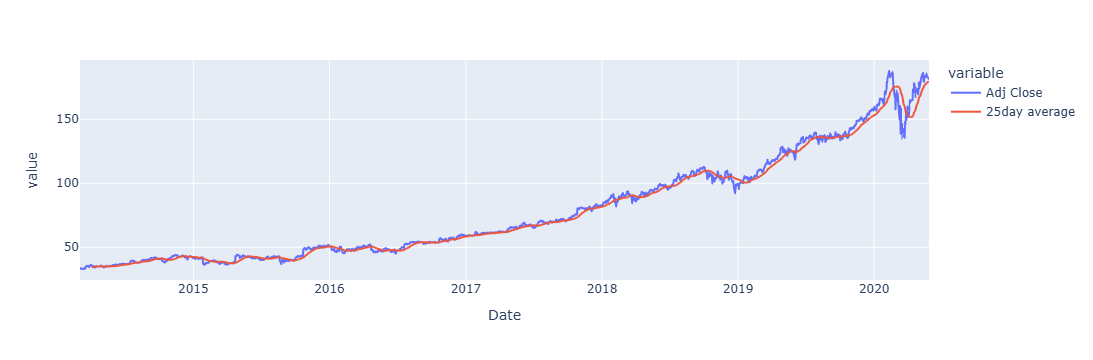

In [113]:
msft14_20.plot()

In [117]:
msft20["Adj Close"].rolling(50).std()   # max, min, count, mean, sum, std, var

Date
2020-01-02          NaN
2020-01-03          NaN
2020-01-06          NaN
2020-01-07          NaN
2020-01-08          NaN
                ...    
2020-05-20    15.364133
2020-05-21    15.454298
2020-05-22    15.111644
2020-05-26    15.189218
2020-05-27    14.562541
Name: Adj Close, Length: 101, dtype: float64

In [118]:
msft20["Adj Close"].rolling(50).var() 

Date
2020-01-02           NaN
2020-01-03           NaN
2020-01-06           NaN
2020-01-07           NaN
2020-01-08           NaN
                 ...    
2020-05-20    236.056569
2020-05-21    238.835336
2020-05-22    228.361799
2020-05-26    230.712354
2020-05-27    212.067595
Name: Adj Close, Length: 101, dtype: float64

## Big data processing frameworks 

Dask      (https://dask.org)

PySpark   (https://spark.apache.org/)

cuDF      (https://docs.rapids.ai/api/cudf/stable/)
